# [실습 9-2] Keras로 MNIST 분류 — 드롭아웃 Before/After

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 40~50분 (CPU 가능, **GPU 권장**) |
| 본문 연계 | 9.5 과적합과 정규화 |
| 선수 실습 | [실습 8-2] (같은 데이터) · [실습 9-1] |
| 준비 | 부록 B.1·B.3 참고 |

8장 실습 8-2에서 PCA로 뭉쳐 보던 **그 데이터**를, 이번에는
라벨을 붙여 6만 장 전체로 학습한다 — 같은 데이터, 표현에서
학습으로. 밑바닥 NumPy(9-1)에서 프레임워크(Keras)로 넘어간다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch09/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import matplotlib.pyplot as plt
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__)

import tensorflow as tf
print("TensorFlow", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus[0].name if gpus else
      "없음 — CPU도 가능(에폭당 수십 초), GPU 권장")

import keras
keras.utils.set_random_seed(9)   # 전체 재현성(저장소 전용)

Python 3.12.6
NumPy 2.4.6


TensorFlow 2.21.0
GPU: 없음 — CPU도 가능(에폭당 수십 초), GPU 권장


### [셀 1] 데이터 적재 — 8장에서 본 그 숫자들 📖

학습 (60000, 28, 28), 평가 (10000, 28, 28)


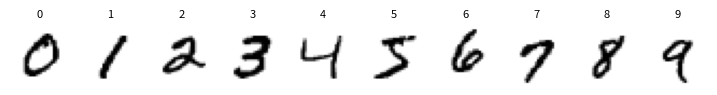

In [2]:
from utils.data import load_mnist

(X_tr, y_tr), (X_te, y_te) = load_mnist()
X_tr, X_te = X_tr / 255.0, X_te / 255.0
print(f"학습 {X_tr.shape}, 평가 {X_te.shape}")
viz.show_digits(X_tr, y_tr, n=10)   # 8-2와 같은 로더

**핵심 포인트**
- `load_mnist()`는 실습 8-2와 동일한 공용 로더다. 8-2가 5,000장 표본으로 '표현'을 봤다면 여기서는 전체로 '학습'한다.
- 픽셀 값을 255로 나눠 0~1로 맞춘다 — 입력 정규화는 7.3 〈거리 척도와 정규화〉에서 배운 그 습관이다.

기대 출력: `학습 (60000, 28, 28), 평가 (10000, 28, 28)`

### [셀 2] 모델 정의 — 지금까지 배운 부품의 조립 📖

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

def build_mlp(dropout=0.0):
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    return model

**핵심 포인트**
- 이 20줄에 9장 전체가 들어 있다 — ReLU 은닉층(9.2), 소프트맥스 출력(9.2 〈출력층 설계〉), 교차 엔트로피 손실(9.3), Adam 옵티마이저와 학습률 0.001(9.3 안전한 시작값).
- 역전파 코드가 보이지 않는 이유 — 프레임워크가 계산 그래프(9.4)를 스스로 그리고 미분해 준다. 우리가 실습 9-1에서 손으로 만든 그 일이다.
- `Dropout(0.0)`은 아무것도 끄지 않는다 — Before 조건이다.

### [셀 3] Before — 드롭아웃 없이 학습 📖

/Users/jungsookim/Library/Python/3.12/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


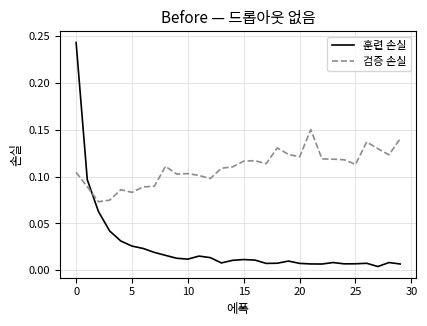

<Axes: title={'center': 'Before — 드롭아웃 없음'}, xlabel='에폭', ylabel='손실'>

In [4]:
base = build_mlp(dropout=0.0)
hist = base.fit(X_tr, y_tr, epochs=30,
                batch_size=64,        # 32~128 범위
                validation_split=0.1,
                verbose=0)
viz.plot_curves(hist, title="Before — 드롭아웃 없음")

**핵심 포인트**
- 훈련 데이터의 10%를 검증용으로 떼어(`validation_split`) 에폭마다 두 손실을 기록한다 — [그림 9-4]가 실시간으로 그려지는 것이다.
- 출력 곡선에서 검증 손실의 반등 시점을 눈으로 찾아보자. 그 에폭 이후는 암기 구간이다.

### [셀 4] After — 드롭아웃 0.3을 넣고 같은 조건으로 📖

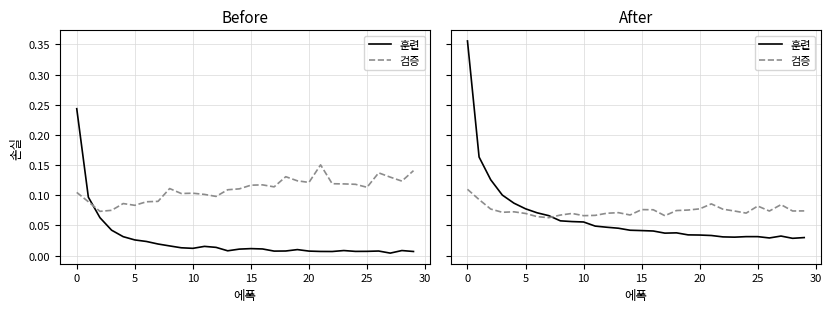

After 평가 정확도: 0.9832


In [5]:
reg = build_mlp(dropout=0.3)   # 시작값 0.2~0.5
hist2 = reg.fit(X_tr, y_tr, epochs=30,
                batch_size=64,
                validation_split=0.1,
                verbose=0)
viz.plot_curves_pair(hist, hist2,
                     labels=("Before", "After"))
te_acc = reg.evaluate(X_te, y_te, verbose=0)[1]
print(f"After 평가 정확도: {te_acc:.4f}")

**핵심 포인트**
- 달라진 것은 `dropout=0.3` 하나다. 겹쳐 그린 곡선에서 After의 훈련-검증 간격이 좁아지고 반등이 사라지거나 늦어지는 것을 확인한다 — [표 9-3] 2번 처방의 효과다.
- After의 '훈련' 정확도가 Before보다 낮게 보이는 것은 정상이다 — 드롭아웃은 학습 중에만 뉴런을 끄므로, 비교는 반드시 '검증' 곡선으로 한다.

실패 시 대처: CPU에서는 에폭당 수십 초가 걸릴 수 있다 — Colab GPU(T4) 전환은 부록 B.1 참고. GPU 연산 특성상 소수점 수치가 지면과 미세하게 다를 수 있다 — 곡선의 경향(반등 유무·간격)이 같으면 정상이다.

### [심화 1] 드롭아웃 비율 × 조기 종료 조합 실험 (연습문제 10번 출발)

In [6]:
# TODO: 드롭아웃 [0.0, 0.2, 0.3, 0.5] × 조기 종료
#       유/무 조합으로 평가 정확도 표를 완성하고,
#       "가장 좋은 조합"과 그 이유를 설명해 보자.
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(patience=3, monitor="val_loss",
                   restore_best_weights=True)
# 예시 뼈대 (에폭 상한 30, 조기 종료로 자동 단축):
# m = build_mlp(dropout=0.2)
# h = m.fit(X_tr, y_tr, epochs=30, batch_size=64,
#           validation_split=0.1, verbose=0,
#           callbacks=[es])
# print(len(h.history["loss"]), "에폭에서 종료",
#       m.evaluate(X_te, y_te, verbose=0)[1])
print("뼈대 준비 완료 — TODO를 채워 실험하세요.")

뼈대 준비 완료 — TODO를 채워 실험하세요.


---
## 마무리

- 같은 데이터가 8장(표현)과 9장(학습)을 관통했다 — `load_mnist()` 한 줄의 연결이다.
- 프레임워크는 9-1에서 손으로 만든 역전파를 대신해 줄 뿐, 마법이 아니다.
- 과적합 진단(검증 곡선 반등)과 처방(드롭아웃)이 코드 인자 하나로 실험된다 — [표 9-3]의 처방전을 [심화 1]에서 계속 시험해 보자.

**연습문제 연계**: [심화] 정규화 조합 실험 설계(구현형) 문항은 [심화 1] 뼈대에서 출발한다.

**다음 장 실습**: [실습 10-1] Keras CNN — CIFAR-10 (`ch10/lab-10-01_cnn-cifar10.ipynb`)